In [1]:
import mynn
from draw_tools.plot import plot
import numpy as np
from struct import unpack
import pickle
import gzip
import matplotlib.pyplot as plt

# fixed seed for experiment
np.random.seed(309)

train_images_path = r'.\dataset\MNIST\train-images-idx3-ubyte.gz'
train_labels_path = r'.\dataset\MNIST\train-labels-idx1-ubyte.gz'

with gzip.open(train_images_path, 'rb') as f:
        magic, num, rows, cols = unpack('>4I', f.read(16))
        train_imgs=np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28*28)
    
with gzip.open(train_labels_path, 'rb') as f:
        magic, num = unpack('>2I', f.read(8))
        train_labs = np.frombuffer(f.read(), dtype=np.uint8)


# choose 10000 samples from train set as validation set.
idx = np.random.permutation(np.arange(num))
# save the index.
with open('idx.pickle', 'wb') as f:
        pickle.dump(idx, f)
train_imgs = train_imgs[idx]
train_labs = train_labs[idx]
valid_imgs = train_imgs[:10000]
valid_labs = train_labs[:10000]
train_imgs = train_imgs[10000:]
train_labs = train_labs[10000:]

# normalize from [0, 255] to [0, 1]
train_imgs = train_imgs / train_imgs.max()
valid_imgs = valid_imgs / valid_imgs.max()



In [12]:
def train_model(nHidden = [128], lr=1.0, epochs=3,early_stop=3, initialize_method='He',dropout_p=None):
    # 模型结构：输入层 + 隐藏层 + 输出层
    size_list = [train_imgs.shape[1]] + nHidden + [10]
    lambda_list = [1e-4] * (len(nHidden) + 1)  # 每层一个lambda
    
    # 初始化组件
    model = mynn.models.Model_MLP(size_list, 'ReLU', lambda_list, dropout_p=dropout_p, initialize_method=initialize_method)
    my_optimizer = mynn.optimizer.MomentGD(init_lr=lr, model=model, mu=0.9)

    scheduler = mynn.lr_scheduler.MultiStepLR(my_optimizer, milestones=[500, 1500, 2500, 3000], gamma=0.5)
    loss_fn = mynn.op.MSELoss(model=model)
    # loss_fn = mynn.op.MultiCrossEntropyLoss(model=model)
    # loss_fn = loss_fn.cancel_soft_max()
    
    # 训练运行器
    trainer = mynn.runner.RunnerM(
        model=model,
        optimizer=my_optimizer,
        metric=mynn.metric.accuracy,
        loss_fn=loss_fn,
        batch_size=32,
        scheduler=scheduler
    )
    
    # 执行训练
    trainer.train(
        train_set=[train_imgs, train_labs],
        dev_set=[valid_imgs, valid_labs],
        num_epochs=epochs,
        log_iters=200,
        early_stop = early_stop,
        save_dir = f'./saved_models/Q4/mse'
    )
    
    _, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 绘制训练和验证损失曲线
    axes[0].plot(trainer.train_loss, label='Train Loss')
    axes[0].plot(trainer.dev_loss, label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Iters')  # x轴标签
    axes[0].set_ylabel('Loss')    # y轴标签
    axes[0].legend()

    # 绘制训练和验证准确度曲线
    axes[1].plot(trainer.train_scores, label='Train Acc')
    axes[1].plot(trainer.dev_scores, label='Val Acc')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Iters')  # x轴标签
    axes[1].set_ylabel('Accuracy')  # y轴标签
    axes[1].legend()

    plt.tight_layout()  # 自动调整布局
    plt.show()
    
    return trainer

### 使用cancel_soft_max方法等价于并未添加softmax(见op.py)

##### 未添加`softmax`层

c:\Users\10317\Desktop\学习\神经网络与深度学习\hw\PJ1\PJ1\codes\mynn\op.py:308: RuntimeWarning: invalid value encountered in log
  loss = -np.sum(y_one_hot * np.log(self.prob + 1e-10)) / self.batch_size


[Iter 200]
[Train] loss: nan, score: 0.21875
[Dev] loss: nan, score: 0.17310
[Iter 400]
[Train] loss: nan, score: 0.12500
[Dev] loss: nan, score: 0.12530
[Iter 600]
[Train] loss: nan, score: 0.12500
[Dev] loss: nan, score: 0.10080
[Iter 800]
[Train] loss: nan, score: 0.09375
[Dev] loss: nan, score: 0.10080
[Iter 1000]
[Train] loss: nan, score: 0.06250
[Dev] loss: nan, score: 0.11030
[Iter 1200]
[Train] loss: nan, score: 0.12500
[Dev] loss: nan, score: 0.10080
[Iter 1400]
[Train] loss: nan, score: 0.15625
[Dev] loss: nan, score: 0.17750
best accuracy updated: 0.00000 --> 0.12080
[Iter 1600]
[Train] loss: nan, score: 0.18750
[Dev] loss: nan, score: 0.16740
[Iter 1800]
[Train] loss: nan, score: 0.03125
[Dev] loss: nan, score: 0.10080
[Iter 2000]
[Train] loss: nan, score: 0.06250
[Dev] loss: nan, score: 0.10080
[Iter 2200]
[Train] loss: nan, score: 0.15625
[Dev] loss: nan, score: 0.15690
[Iter 2400]
[Train] loss: nan, score: 0.18750
[Dev] loss: nan, score: 0.10160
[Iter 2600]
[Train] loss:

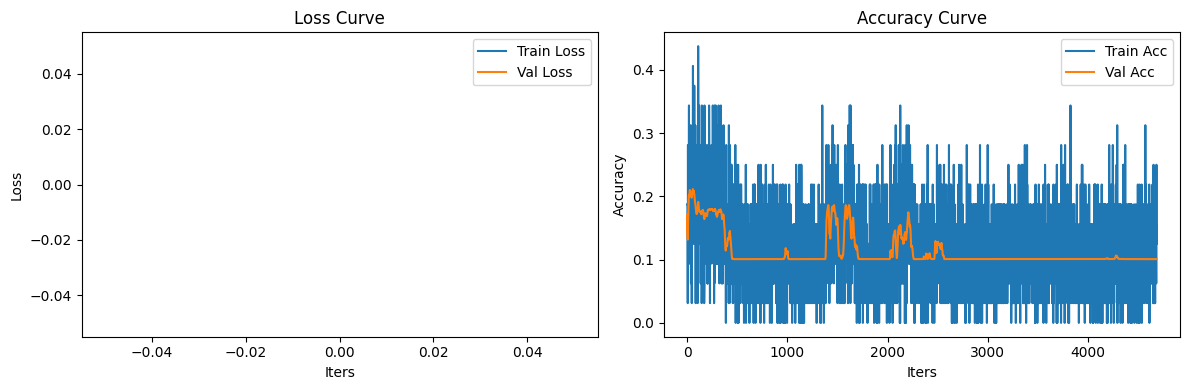

Best train set accuracy: 0.4375
Best validation set accuracy: 0.1208


In [3]:
train1 = train_model()
print("Best train set accuracy:", max(train1.train_scores))
print("Best validation set accuracy:", train1.best_score)

### 不使用cancel_soft_max方法等价于并添加了一层softmax(见op.py)

##### 添加`softmax`层

[Iter 200]
[Train] loss: 0.34715, score: 0.90625
[Dev] loss: 0.35293, score: 0.89650
[Iter 400]
[Train] loss: 0.22037, score: 0.93750
[Dev] loss: 0.28861, score: 0.91640
[Iter 600]
[Train] loss: 0.38927, score: 0.81250
[Dev] loss: 0.25463, score: 0.92750
[Iter 800]
[Train] loss: 0.11684, score: 0.96875
[Dev] loss: 0.22556, score: 0.93610
[Iter 1000]
[Train] loss: 0.21625, score: 0.90625
[Dev] loss: 0.22943, score: 0.93640
[Iter 1200]
[Train] loss: 0.14937, score: 0.96875
[Dev] loss: 0.21973, score: 0.93910
[Iter 1400]
[Train] loss: 0.43700, score: 0.84375
[Dev] loss: 0.21446, score: 0.94100
best accuracy updated: 0.00000 --> 0.94890
[Iter 1600]
[Train] loss: 0.09640, score: 0.96875
[Dev] loss: 0.19797, score: 0.94620
[Iter 1800]
[Train] loss: 0.15636, score: 0.93750
[Dev] loss: 0.19160, score: 0.94830
[Iter 2000]
[Train] loss: 0.10424, score: 0.96875
[Dev] loss: 0.19050, score: 0.94950
[Iter 2200]
[Train] loss: 0.09577, score: 1.00000
[Dev] loss: 0.18874, score: 0.94980
[Iter 2400]
[Tr

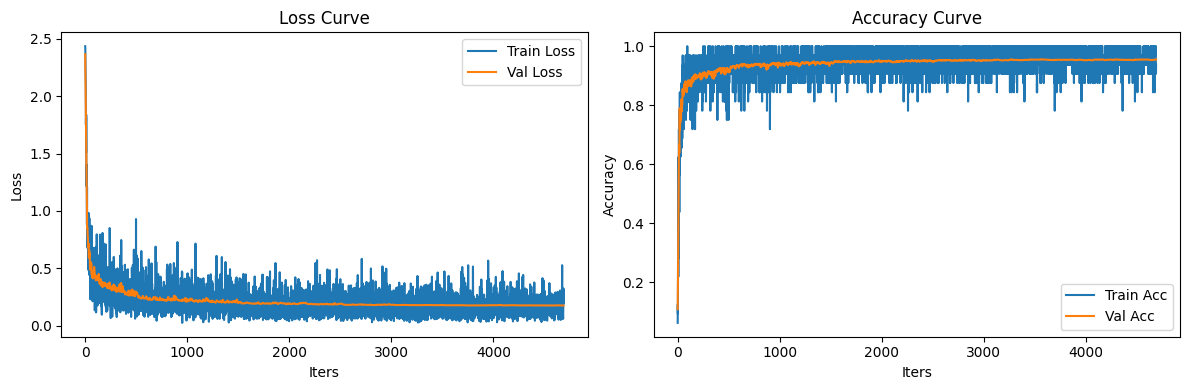

Best train set accuracy: 1.0
Best validation set accuracy: 0.955


In [11]:
train2 = train_model()
print("Best train set accuracy:", max(train2.train_scores))
print("Best validation set accuracy:", train2.best_score)

### 若使用平方损失（Mean Squared Error Loss）来作为损失函数

#####   将`loss_fn = mynn.op.MultiCrossEntropyLoss(model=model)`替换为`loss_fn = mynn.op.MSELoss(model=model)`


[Iter 200]
[Train] loss: 0.33050, score: 0.81250
[Dev] loss: 0.25942, score: 0.88720
[Iter 400]
[Train] loss: 0.26707, score: 0.87500
[Dev] loss: 0.21641, score: 0.91070
[Iter 600]
[Train] loss: 0.20433, score: 0.90625
[Dev] loss: 0.19002, score: 0.91640
[Iter 800]
[Train] loss: 0.08671, score: 1.00000
[Dev] loss: 0.17835, score: 0.92920
[Iter 1000]
[Train] loss: 0.12290, score: 1.00000
[Dev] loss: 0.17758, score: 0.93100
[Iter 1200]
[Train] loss: 0.17603, score: 0.90625
[Dev] loss: 0.17432, score: 0.93370
[Iter 1400]
[Train] loss: 0.15456, score: 0.90625
[Dev] loss: 0.16833, score: 0.93670
best accuracy updated: 0.00000 --> 0.93820
[Iter 1600]
[Train] loss: 0.15072, score: 0.93750
[Dev] loss: 0.16023, score: 0.93630
[Iter 1800]
[Train] loss: 0.16955, score: 0.93750
[Dev] loss: 0.15714, score: 0.93960
[Iter 2000]
[Train] loss: 0.11488, score: 0.96875
[Dev] loss: 0.15061, score: 0.94150
[Iter 2200]
[Train] loss: 0.16580, score: 0.93750
[Dev] loss: 0.15245, score: 0.94180
[Iter 2400]
[Tr

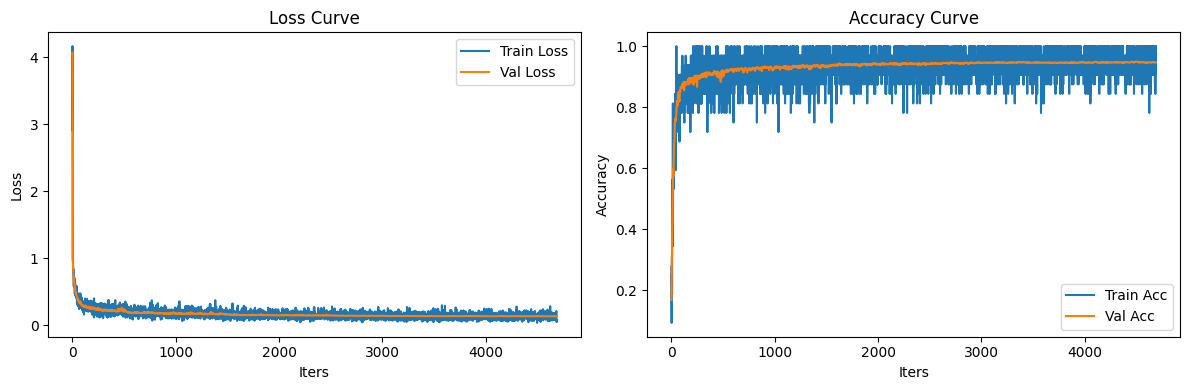

Best train set accuracy: 1.0
Best validation set accuracy: 0.947


In [13]:
train3 = train_model()
print("Best train set accuracy:", max(train3.train_scores))
print("Best validation set accuracy:", train3.best_score)

### 对比

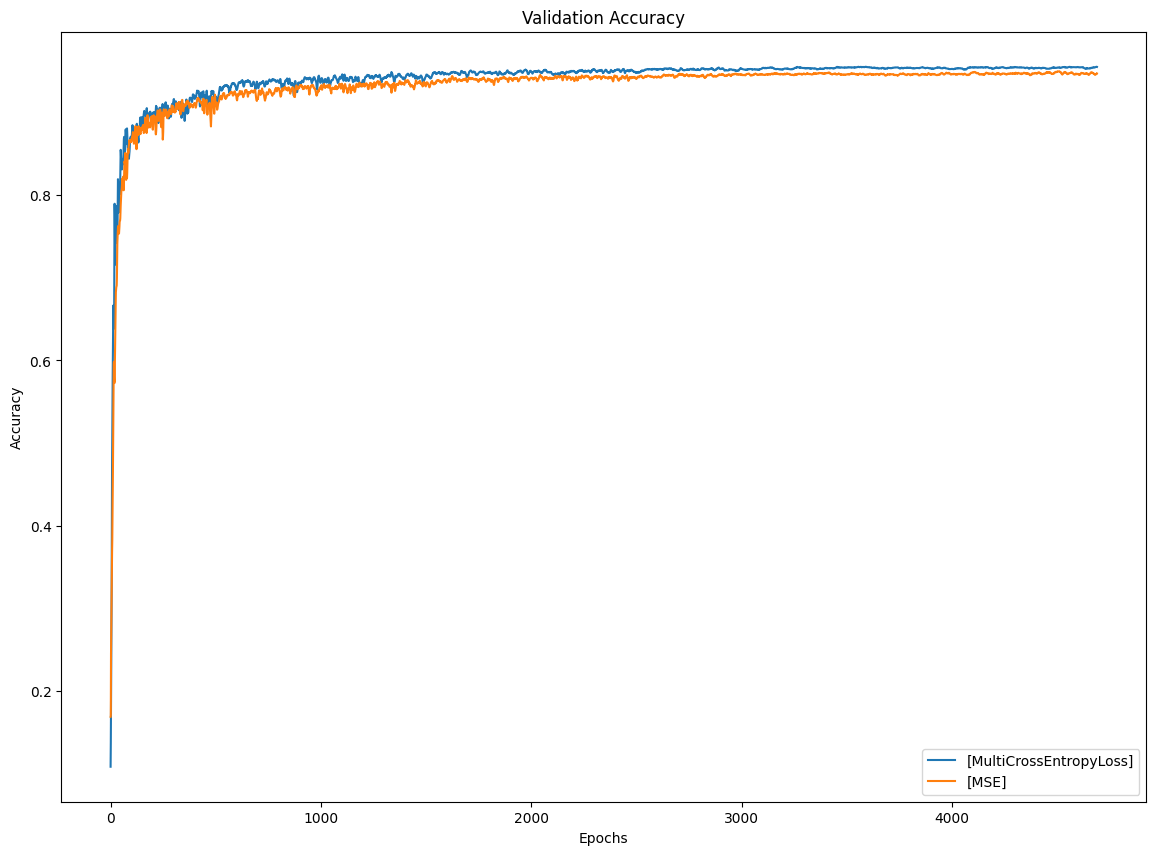

In [14]:
# Plotting the results
plt.figure(figsize=(14, 10))
plt.plot(train2.dev_scores, label='[MultiCrossEntropyLoss]')
plt.plot(train3.dev_scores, label='[MSE]')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#### 可以发现MSE和MultiCrossEntropyLoss最终效果差不多，但是MultiCrossEntropyLoss还是优于MSE一点。